# GS - Generative AI for Engineering
## AstraFarm Irrigation Advisor: predição da necessidade de irrigação (litros/m²) com MLP e XGBoost

**Tema:** Agricultura inteligente
**Contexto:** módulo da plataforma AstraFarm para recomendar
quanto irrigar cada talhão com base em dados de solo e clima, complementando
a infraestrutura SECDEVOPS já documentada pela equipe.

**Algoritmos utilizados:**
- Pré-tratamento com `StandardScaler` (Aula 04)
- *Feature Selection* — correlação, RFE e importância XGBoost (Aula 09)
- **MLPRegressor** do scikit-learn (Aulas 04-05)
- **XGBRegressor** (Aulas 06 e 11)
- Avaliação com **R²** e **MAPE %** (Aulas 04, 11)
- **Deploy** com `joblib` + `gradio` (Aula 11)

---

| # | Critério do GS | Onde está | Pontos |
|---|----------------|-----------|--------|
| 1 | Definição do problema | §1 | 1,0 |
| 2 | Dataset | §2 | 1,0 |
| 3 | Tratamento e preparação | §3 | 1,0 |
| 4 | Técnicas de treinamento (MLP + XGBoost + FS) | §4 | 3,0 |
| 5 | Avaliação por métricas | §5 | 1,0 |
| 6 | Avaliação visual | §6 | 1,0 |
| 7 | Código, documentação e deploy | repo + §7 | 2,0 |


## 1. Definição do problema  *(1,0)*

Em fazendas terrestres modernas e em estufas espaciais (AstraFarm, NASA *Veggie*,
ESA *EDEN ISS*), a água é um recurso limitado. Irrigar a mais desperdiça; irrigar
a menos compromete a produção.

**Tarefa:** dado o estado atual do solo (níveis de N, P, K, pH) e do clima
(temperatura, umidade, chuva), predizer **quantos litros/m² devem ser irrigados
artificialmente no próximo ciclo**.

É um **problema de regressão tabular**, próximo do estudo de caso de California
Housing trabalhado na disciplina.

### Como derivamos a necessidade de irrigação (target)
O dataset usado é o *Crop Recommendation Dataset* (Indian agricultural data),
que originalmente é de classificação (qual cultura plantar). Convertemos para
regressão de irrigação aplicando um **balanço hídrico simplificado** baseado na
fórmula FAO de evapotranspiração de referência:

$$ \text{Irrigação} = \max(0,\ \text{ET}_c - \text{Chuva efetiva}) $$

onde a evapotranspiração da cultura $\text{ET}_c$ cresce com temperatura e
decresce com umidade do ar, e a chuva efetiva é ~80% da chuva total registrada.
O resultado fica em litros/m² por mês.

Em seguida, adicionamos um **ruído gaussiano** ao target para simular variações
de sensores e condições de campo. Sem isso, o alvo seria uma função determinística
das features.


## 2. Dataset  *(1,0)*

**Crop Recommendation Dataset** — 2.200 registros agrícolas reais coletados na
Índia, com variáveis de solo e clima por cultura.

- 7 variáveis numéricas: `N, P, K, temperature, humidity, ph, rainfall`
- 1 variável categórica: `label` (22 culturas: arroz, milho, banana, café, etc.)
- Sem dados faltantes, balanceado (100 amostras por cultura)
- Disponível publicamente no GitHub (sem necessidade de login Kaggle)
- Domínio público / uso acadêmico


In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

import joblib
import os

os.makedirs("outputs", exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Carrega o dataset direto do GitHub
URL = ("https://raw.githubusercontent.com/gireesh777/"
       "Crop_Recommendation_System_using_ML/master/Dataset/"
       "Crop_recommendation.csv")
df = pd.read_csv(URL)

print("Shape:", df.shape)
print("\nPrimeiras linhas:")
df.head()

Shape: (2200, 8)

Primeiras linhas:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Informações gerais
df.info()
print("\nEstatísticas descritivas:")
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Estatísticas descritivas:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


## 3. Tratamento e preparação dos dados  *(1,0)*

Etapas:

1. **Criação do target de irrigação** a partir das variáveis ambientais
   (balanço hídrico simplificado FAO).
2. **Codificação one-hot** da variável categórica `label` (cultura), pois MLP e
   XGBoost trabalham com variáveis numéricas.

3. **Análise de outliers** via boxplot.
4. **Normalização** com `StandardScaler` (Aula 04): transforma cada variável
   para média 0 e desvio padrão 1.
5. **Split treino/teste** 70/30 com `train_test_split` (Aula 04).


In [4]:
# ---- 3.1 Criação do target: irrigação necessária (L/m² por mês) ----
# Fórmula simplificada de balanço hídrico:
#   - Evapotranspiração da cultura aumenta com temp. e diminui com umidade.
#   - Chuva efetiva = 80% da chuva total (perdas por escoamento e percolação).
#   - Irrigação artificial = max(0, ET_c - chuva efetiva).

def calcular_irrigacao(row):
    # ET_c (mm/mês) — aproximação agronômica baseada em Hargreaves simplificado
    # Forte dependência da temperatura, modulada por umidade.
    ETc = 4.5 * row["temperature"] * (1 - row["humidity"] / 200)
    chuva_efetiva = 0.8 * row["rainfall"]
    irrigacao_mm = max(0.0, ETc - chuva_efetiva)
    # 1 mm em 1 m² = 1 litro -> converte para L/m².
    return irrigacao_mm

df["irrigacao_litros_m2"] = df.apply(calcular_irrigacao, axis=1)

# Adiciona ruído gaussiano para simular imperfeição de sensores reais
# (sem ruído, o alvo seria função 100% determinística das features, e o
#  modelo apenas decoraria a fórmula — com ruído, o problema fica realista).
rng = np.random.default_rng(RANDOM_STATE)
df["irrigacao_litros_m2"] = (
    df["irrigacao_litros_m2"] + rng.normal(0, 2.5, size=len(df))
).clip(lower=1.0)  # piso de 1 L/m² (evita zero e divisão por zero no MAPE)

print("Estatísticas do target (litros/m² por mês):")
print(df["irrigacao_litros_m2"].describe().round(2))

Estatísticas do target (litros/m² por mês):
count    2200.00
mean       15.62
std        18.52
min         1.00
25%         1.00
50%         3.58
75%        30.10
max        87.41
Name: irrigacao_litros_m2, dtype: float64


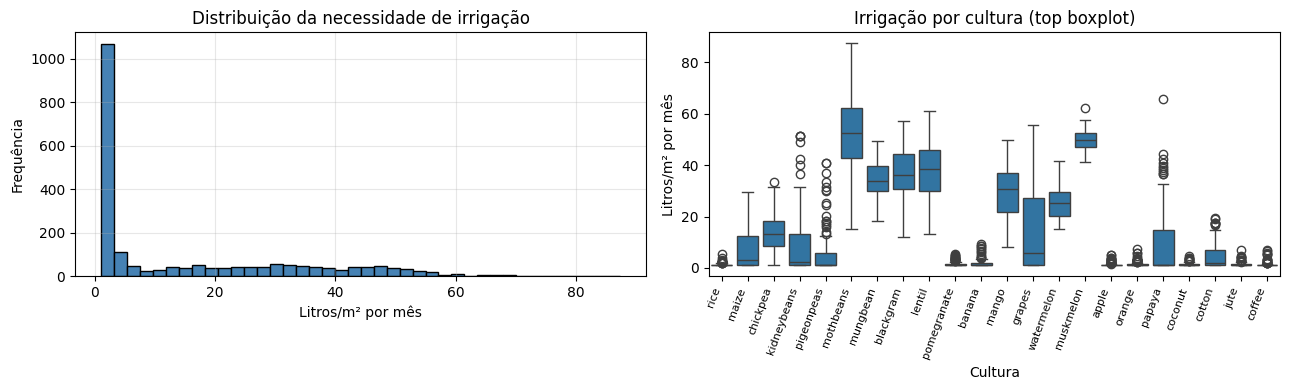

In [5]:
# Visualiza a distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["irrigacao_litros_m2"], bins=40, color="steelblue",
             edgecolor="black")
axes[0].set_title("Distribuição da necessidade de irrigação")
axes[0].set_xlabel("Litros/m² por mês"); axes[0].set_ylabel("Frequência")
axes[0].grid(alpha=0.3)

sns.boxplot(x="label", y="irrigacao_litros_m2", data=df, ax=axes[1])
axes[1].set_title("Irrigação por cultura (top boxplot)")
axes[1].set_xlabel("Cultura"); axes[1].set_ylabel("Litros/m² por mês")
plt.setp(axes[1].get_xticklabels(), rotation=70, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/01_distribuicao_target.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# ---- 3.2 One-hot encoding da cultura ----
df_enc = pd.get_dummies(df, columns=["label"], prefix="crop", dtype=int)
print(f"Shape após one-hot: {df_enc.shape}")
print(f"Colunas de cultura criadas: {sum(c.startswith('crop_') for c in df_enc.columns)}")
df_enc.head()

Shape após one-hot: (2200, 30)
Colunas de cultura criadas: 22


,N,P,K,temperature,humidity,ph,rainfall,irrigacao_litros_m2,crop_apple,crop_banana,...,crop_mango,crop_mothbeans,crop_mungbean,crop_muskmelon,crop_orange,crop_papaya,crop_pigeonpeas,crop_pomegranate,crop_rice,crop_watermelon
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1.000000,0,0,...,0,0,0,0,0,0,0,0,1,0
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1.000000,0,0,...,0,0,0,0,0,0,0,0,1,0
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1.876128,0,0,...,0,0,0,0,0,0,0,0,1,0
3,74,35,40,26.491096,80.158363,6.980401,242.864034,2.351412,0,0,...,0,0,0,0,0,0,0,0,1,0
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1.000000,0,0,...,0,0,0,0,0,0,0,0,1,0


In [7]:
# ---- 3.3 Separação X / y ----
y = df_enc["irrigacao_litros_m2"]
X = df_enc.drop(columns=["irrigacao_litros_m2"])

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (2200, 29)
Target (y): (2200,)


In [8]:
# ---- 3.4 Normalização (StandardScaler) ----
# Aplicada apenas às variáveis numéricas originais; as one-hot ficam como estão.
numerical_columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_columns] = scaler.fit_transform(X[numerical_columns])

print("Após normalização (variáveis numéricas):")
X_scaled[numerical_columns].describe().round(3)

Após normalização (variáveis numéricas):


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000,2200.000
mean,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.370,-1.466,-0.852,-3.317,-2.571,-3.832,-1.515
25%,-0.801,-0.769,-0.556,-0.562,-0.504,-0.643,-0.708
50%,-0.367,-0.072,-0.319,-0.003,0.404,-0.057,-0.156
75%,0.913,0.444,0.017,0.582,0.830,0.587,0.379
max,2.423,2.779,3.098,3.567,1.280,4.479,3.551


In [9]:
# ---- 3.5 Split treino/teste ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_STATE)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 1540 amostras
Teste:  660 amostras


## 4. Técnicas para treinamento do modelo  *(3,0)*

Nesta seção são aplicados três blocos de técnicas da disciplina:

1. **Feature Selection** (Aula 09) — comparando 3 métodos.
2. **MLPRegressor** (Aulas 04-05) — rede neural multicamadas.
3. **XGBRegressor** (Aulas 06 e 11) — gradient boosting.

E ao final, comparamos os dois modelos lado a lado.


### 4.1 Feature Selection (Aula 09)

Foram aplicadas três abordagens de seleção de atributos sobre as 7 variáveis
numéricas originais. As colunas one-hot foram mantidas fora dessa comparação por
representarem culturas específicas.

- **Filtro:** matriz de correlação de Pearson.
- **Wrapper:** *Recursive Feature Elimination* (RFE) com `XGBRegressor` como base.
- **Embedded:** importância de features do XGBoost treinado.


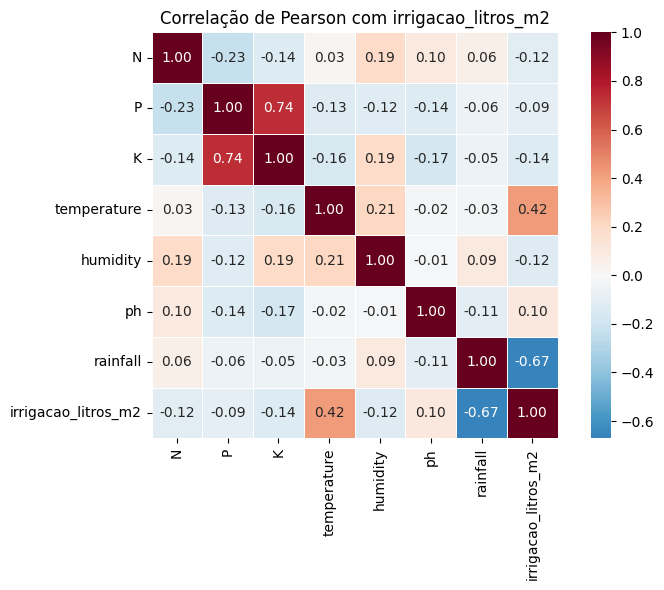


Correlação absoluta com o target:
rainfall       0.672
temperature    0.421
K              0.135
humidity       0.124
N              0.115
ph             0.103
P              0.093
Name: irrigacao_litros_m2, dtype: float64


In [10]:
# 4.1.1 — Filtro: matriz de correlação
plt.figure(figsize=(8, 6))
corr = df[numerical_columns + ["irrigacao_litros_m2"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5)
plt.title("Correlação de Pearson com irrigacao_litros_m2")
plt.tight_layout()
plt.savefig("outputs/02_correlacao.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nCorrelação absoluta com o target:")
print(corr["irrigacao_litros_m2"].drop("irrigacao_litros_m2")
      .abs().sort_values(ascending=False).round(3))

In [11]:
# 4.1.2 — Wrapper: RFE (Recursive Feature Elimination)
# Seleciona iterativamente as N features mais importantes usando um estimador.
rfe_estimator = XGBRegressor(n_estimators=200, max_depth=4,
                             learning_rate=0.1, random_state=RANDOM_STATE,
                             verbosity=0)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=4)
rfe.fit(X_train[numerical_columns], y_train)

rfe_resultado = pd.DataFrame({
    "feature": numerical_columns,
    "selecionada": rfe.support_,
    "ranking": rfe.ranking_
}).sort_values("ranking")
print("Resultado do RFE (top 4 features selecionadas):")
print(rfe_resultado)

Resultado do RFE (top 4 features selecionadas):
       feature  selecionada  ranking
0            N         True        1
3  temperature         True        1
6     rainfall         True        1
4     humidity         True        1
1            P        False        2
5           ph        False        3
2            K        False        4


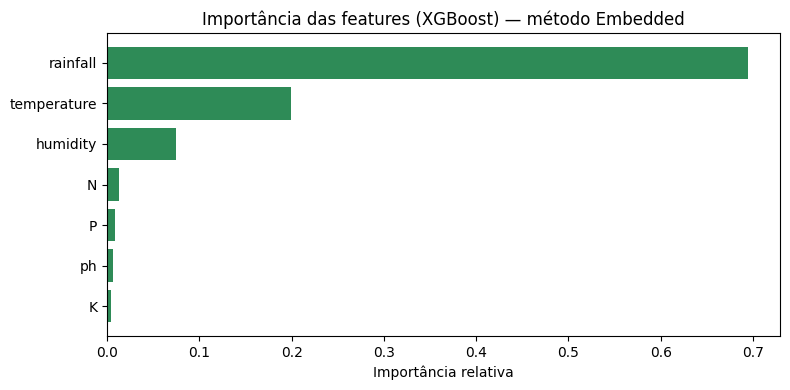


Ranking de importância:
       feature  importancia
6     rainfall        0.695
3  temperature        0.199
4     humidity        0.074
0            N        0.013
1            P        0.008
5           ph        0.007
2            K        0.004


In [12]:
# 4.1.3 — Embedded: importância do XGBoost
xgb_for_importance = XGBRegressor(n_estimators=300, max_depth=4,
                                   learning_rate=0.1,
                                   random_state=RANDOM_STATE,
                                   verbosity=0)
xgb_for_importance.fit(X_train[numerical_columns], y_train)

importancia = pd.DataFrame({
    "feature": numerical_columns,
    "importancia": xgb_for_importance.feature_importances_
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importancia["feature"], importancia["importancia"], color="seagreen")
plt.gca().invert_yaxis()
plt.title("Importância das features (XGBoost) — método Embedded")
plt.xlabel("Importância relativa")
plt.tight_layout()
plt.savefig("outputs/03_importancia_features.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nRanking de importância:")
print(importancia.round(3))

**Conclusão da Feature Selection:** os três métodos indicam **temperature**,
**humidity** e **rainfall** como as features mais relevantes. Isso é coerente com
o balanço hídrico: temperatura aumenta evapotranspiração; umidade e chuva reduzem
a necessidade de irrigação artificial.

Para o treinamento, mantemos **todas** as features (numéricas + one-hot de
cultura). A Feature Selection foi usada principalmente para interpretação e
checagem agronômica do modelo.


### 4.2 Modelo 1 — MLPRegressor (Aulas 04 e 05)

Rede neural com 2 camadas ocultas:
`hidden_layer_sizes=(64, 32)`.


In [13]:
# Modelo MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    n_iter_no_change=50,
    verbose=False,
    random_state=RANDOM_STATE
)

mlp.fit(X_train, y_train)

# Predições
y_pred_train_mlp = mlp.predict(X_train)
y_pred_test_mlp = mlp.predict(X_test)

# Métricas do modelo
r2_train_mlp = r2_score(y_train, y_pred_train_mlp)
r2_test_mlp = r2_score(y_test, y_pred_test_mlp)
mape_train_mlp = mean_absolute_percentage_error(y_train, y_pred_train_mlp)
mape_test_mlp = mean_absolute_percentage_error(y_test, y_pred_test_mlp)
mae_train_mlp = mean_absolute_error(y_train, y_pred_train_mlp)
mae_test_mlp = mean_absolute_error(y_test, y_pred_test_mlp)

print("===== MLPRegressor =====")
print(f"Treino  -> R²: {r2_train_mlp:.4f} | MAPE: {mape_train_mlp*100:.2f}% | MAE: {mae_train_mlp:.2f} L/m²")
print(f"Teste   -> R²: {r2_test_mlp:.4f} | MAPE: {mape_test_mlp*100:.2f}% | MAE: {mae_test_mlp:.2f} L/m²")

===== MLPRegressor =====
Treino  -> R²: 0.9910 | MAPE: 28.61% | MAE: 1.23 L/m²
Teste   -> R²: 0.9882 | MAPE: 37.70% | MAE: 1.44 L/m²


c:\Users\Henrique\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


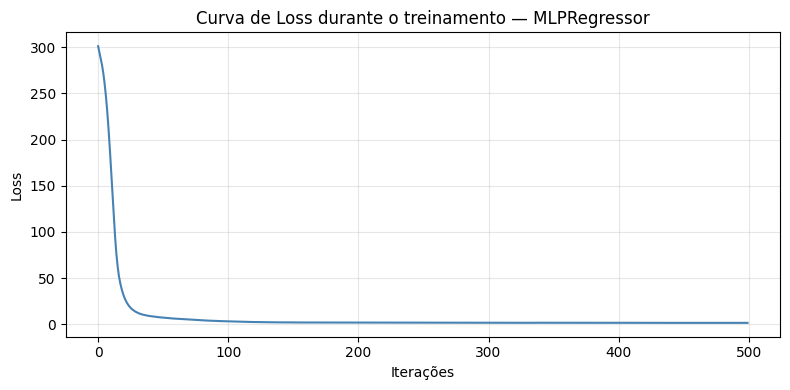

In [14]:
# Curva de loss do MLP
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color="steelblue")
plt.title("Curva de Loss durante o treinamento — MLPRegressor")
plt.xlabel("Iterações")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/04_loss_mlp.png", dpi=130, bbox_inches="tight")
plt.show()

### 4.3 Modelo 2 — XGBRegressor (Aulas 06 e 11)

Configuração usada para o XGBoost:
`n_estimators=1000`, `max_depth=4`, `learning_rate=0.1`.


In [15]:
# Modelo XGBoost
xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb.fit(X_train, y_train)

# Predições
y_pred_train_xgb = xgb.predict(X_train)
y_pred_test_xgb = xgb.predict(X_test)

# Métricas
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)
mape_train_xgb = mean_absolute_percentage_error(y_train, y_pred_train_xgb)
mape_test_xgb = mean_absolute_percentage_error(y_test, y_pred_test_xgb)
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)

print("===== XGBRegressor =====")
print(f"Treino  -> R²: {r2_train_xgb:.4f} | MAPE: {mape_train_xgb*100:.2f}% | MAE: {mae_train_xgb:.2f} L/m²")
print(f"Teste   -> R²: {r2_test_xgb:.4f} | MAPE: {mape_test_xgb*100:.2f}% | MAE: {mae_test_xgb:.2f} L/m²")

===== XGBRegressor =====
Treino  -> R²: 0.9997 | MAPE: 8.44% | MAE: 0.24 L/m²
Teste   -> R²: 0.9771 | MAPE: 47.31% | MAE: 1.90 L/m²


### 4.4 Interpretabilidade — SHAP

Além das métricas, foi usado SHAP no XGBoost para estimar a contribuição média de cada variável na predição de irrigação.


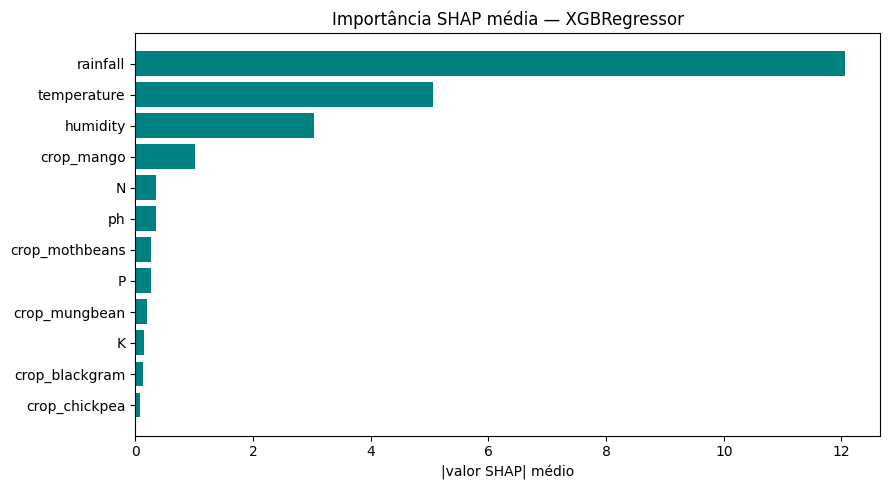

Top variáveis por impacto SHAP médio:
       feature  shap_medio_abs
      rainfall          12.052
   temperature           5.056
      humidity           3.030
    crop_mango           1.013
             N           0.351
            ph           0.343
crop_mothbeans           0.264
             P           0.261
 crop_mungbean           0.191
             K           0.144
crop_blackgram           0.128
 crop_chickpea           0.086


In [16]:
# Interpretabilidade SHAP do XGBoost
try:
    import shap
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

# Amostra pequena para manter a execução rápida no notebook/Colab
X_shap = X_test.sample(n=min(200, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)

shap_importancia = pd.DataFrame({
    "feature": X_shap.columns,
    "shap_medio_abs": np.abs(shap_values).mean(axis=0)
}).sort_values("shap_medio_abs", ascending=False).head(12)

plt.figure(figsize=(9, 5))
plt.barh(shap_importancia["feature"], shap_importancia["shap_medio_abs"], color="teal")
plt.gca().invert_yaxis()
plt.title("Importância SHAP média — XGBRegressor")
plt.xlabel("|valor SHAP| médio")
plt.tight_layout()
plt.savefig("outputs/08_shap_importancia.png", dpi=130, bbox_inches="tight")
plt.show()

print("Top variáveis por impacto SHAP médio:")
print(shap_importancia.round(3).to_string(index=False))


## 5. Avaliação por métricas de desempenho  *(1,0)*

Comparação dos dois modelos usando R², MAPE % e **MAE** (erro absoluto médio em
L/m²). O MAE foi destacado por indicar o erro médio na mesma unidade do problema.


In [17]:
# Tabela comparativa
resultados = pd.DataFrame({
    "Modelo": ["MLPRegressor", "XGBRegressor"],
    "R² (teste)": [r2_test_mlp, r2_test_xgb],
    "MAE (teste) L/m²": [mae_test_mlp, mae_test_xgb],
    "MAPE % (teste)": [mape_test_mlp * 100, mape_test_xgb * 100],
}).round(4)

print("=" * 70)
print("COMPARATIVO DE MODELOS — necessidade de irrigação (L/m²)")
print("=" * 70)
print(resultados.to_string(index=False))

print("\nNota sobre o MAPE: como o target tem alguns valores pequenos "
      "(perto de 1 L/m²),\no MAPE fica inflado (dividir o erro por um "
      "valor pequeno gera percentual alto).\nPor isso o MAE — erro médio "
      "em litros/m² — é a métrica\nprincipal aqui, "
      "com R² medindo o ajuste geral.")

# Salva métricas em JSON (para o GitHub)
import json
with open("outputs/metricas.json", "w") as f:
    json.dump({
        "MLPRegressor": {
            "r2_treino": float(r2_train_mlp), "r2_teste": float(r2_test_mlp),
            "mae_teste_litros_m2": float(mae_test_mlp),
            "mape_teste_pct": float(mape_test_mlp * 100)
        },
        "XGBRegressor": {
            "r2_treino": float(r2_train_xgb), "r2_teste": float(r2_test_xgb),
            "mae_teste_litros_m2": float(mae_test_xgb),
            "mape_teste_pct": float(mape_test_xgb * 100)
        }
    }, f, indent=2, ensure_ascii=False)

print("\nMétricas salvas em outputs/metricas.json")

COMPARATIVO DE MODELOS — necessidade de irrigação (L/m²)
      Modelo  R² (teste)  MAE (teste) L/m²  MAPE % (teste)
MLPRegressor      0.9882            1.4406         37.7019
XGBRegressor      0.9771            1.9008         47.3101

Nota sobre o MAPE: como o target tem alguns valores pequenos (perto de 1 L/m²),
o MAPE fica inflado (dividir o erro por um valor pequeno gera percentual alto).
Por isso o MAE — erro médio em litros/m² — é a métrica
principal aqui, com R² medindo o ajuste geral.

Métricas salvas em outputs/metricas.json


## 6. Avaliação visual do modelo  *(1,0)*

Quatro visualizações complementares:

1. **Predito vs Real** — quanto mais próximo da diagonal, melhor.
2. **Distribuição dos resíduos** — devem ser centrados em zero.
3. **Comparação de barras** R² e MAPE entre os dois modelos.
4. **Mapa interativo** (plotly express) — distribuição
   geográfica simulada da irrigação prevista.


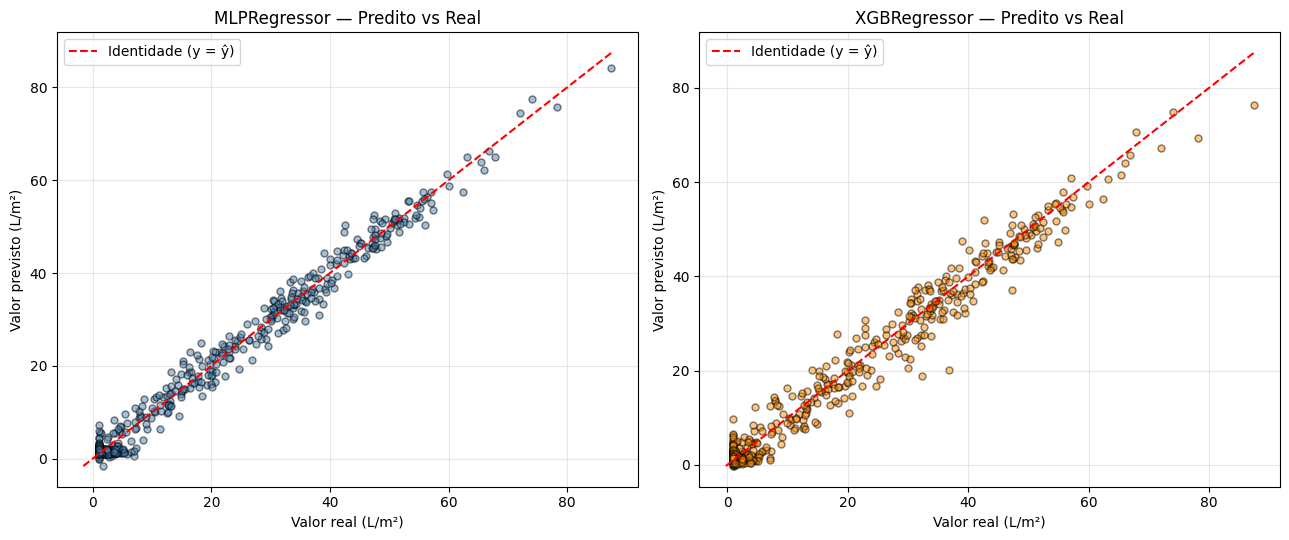

In [18]:
# 6.1 - Predito vs Real (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, y_pred, nome, cor in [
    (axes[0], y_pred_test_mlp, "MLPRegressor", "steelblue"),
    (axes[1], y_pred_test_xgb, "XGBRegressor", "darkorange")
]:
    ax.scatter(y_test, y_pred, alpha=0.5, color=cor, edgecolor="k", s=25)
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lim, lim, "r--", label="Identidade (y = ŷ)")
    ax.set_xlabel("Valor real (L/m²)")
    ax.set_ylabel("Valor previsto (L/m²)")
    ax.set_title(f"{nome} — Predito vs Real")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/05_predito_vs_real.png", dpi=130, bbox_inches="tight")
plt.show()

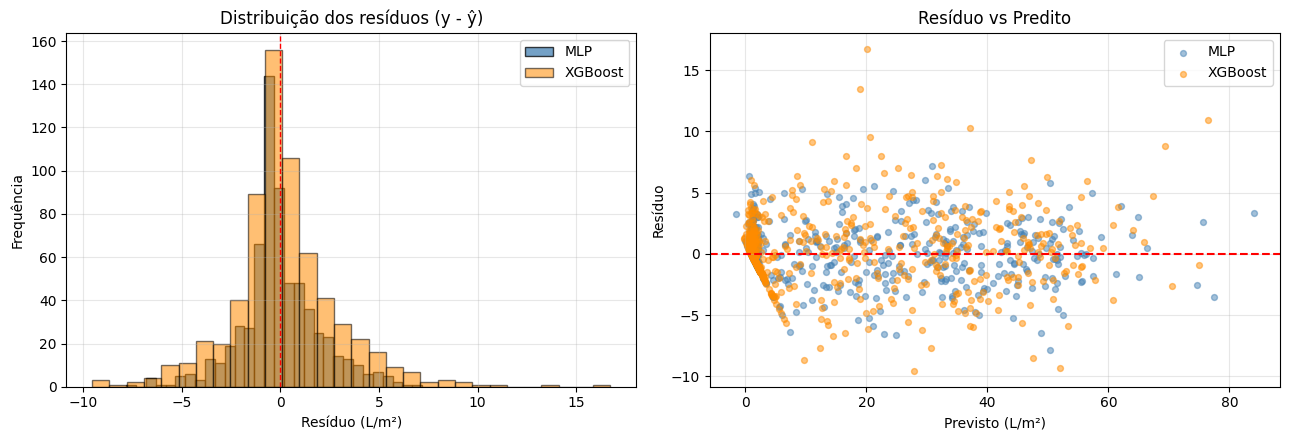

Resíduo médio MLP:     -0.039 L/m²  (deve ser ~0)
Resíduo médio XGBoost: +0.211 L/m²  (deve ser ~0)


In [19]:
# 6.2 - Resíduos
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

residuos_mlp = y_test - y_pred_test_mlp
residuos_xgb = y_test - y_pred_test_xgb

axes[0].hist(residuos_mlp, bins=30, color="steelblue", edgecolor="black",
             alpha=0.75, label="MLP")
axes[0].hist(residuos_xgb, bins=30, color="darkorange", edgecolor="black",
             alpha=0.55, label="XGBoost")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribuição dos resíduos (y - ŷ)")
axes[0].set_xlabel("Resíduo (L/m²)")
axes[0].set_ylabel("Frequência")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_test_mlp, residuos_mlp, alpha=0.5,
                color="steelblue", label="MLP", s=18)
axes[1].scatter(y_pred_test_xgb, residuos_xgb, alpha=0.5,
                color="darkorange", label="XGBoost", s=18)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Resíduo vs Predito")
axes[1].set_xlabel("Previsto (L/m²)")
axes[1].set_ylabel("Resíduo")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/06_residuos.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Resíduo médio MLP:     {residuos_mlp.mean():+.3f} L/m²  (deve ser ~0)")
print(f"Resíduo médio XGBoost: {residuos_xgb.mean():+.3f} L/m²  (deve ser ~0)")

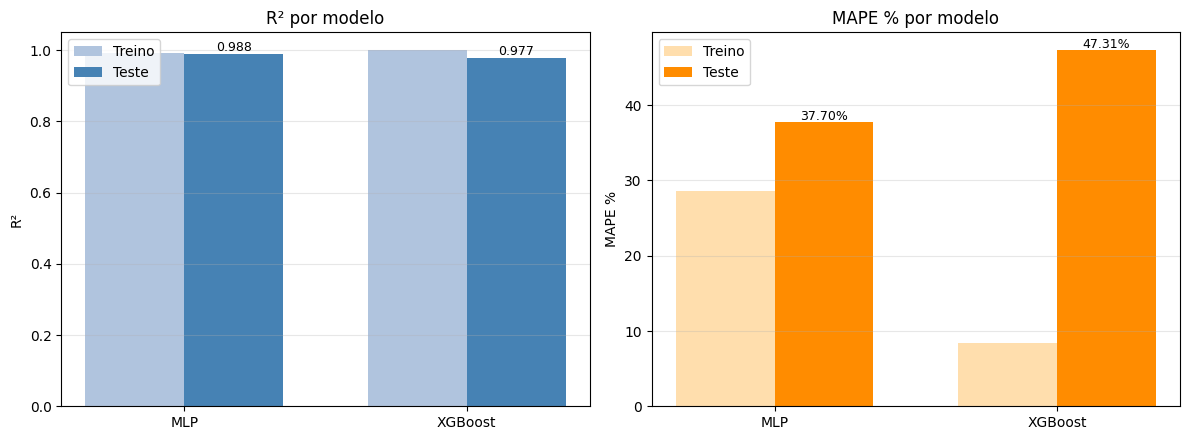

In [20]:
# 6.3 - Comparativo R² e MAPE
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

modelos = ["MLP", "XGBoost"]
r2_tr = [r2_train_mlp, r2_train_xgb]
r2_te = [r2_test_mlp, r2_test_xgb]
mape_tr = [mape_train_mlp * 100, mape_train_xgb * 100]
mape_te = [mape_test_mlp * 100, mape_test_xgb * 100]

x = np.arange(len(modelos)); w = 0.35
axes[0].bar(x - w/2, r2_tr, w, label="Treino", color="lightsteelblue")
axes[0].bar(x + w/2, r2_te, w, label="Teste", color="steelblue")
axes[0].set_xticks(x); axes[0].set_xticklabels(modelos)
axes[0].set_ylabel("R²"); axes[0].set_title("R² por modelo")
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")
for i, v in enumerate(r2_te):
    axes[0].text(i + w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(x - w/2, mape_tr, w, label="Treino", color="navajowhite")
axes[1].bar(x + w/2, mape_te, w, label="Teste", color="darkorange")
axes[1].set_xticks(x); axes[1].set_xticklabels(modelos)
axes[1].set_ylabel("MAPE %"); axes[1].set_title("MAPE % por modelo")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(mape_te):
    axes[1].text(i + w/2, v + 0.3, f"{v:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/07_comparativo_modelos.png", dpi=130, bbox_inches="tight")
plt.show()

In [21]:
# 6.4 - Mapa interativo (plotly express)
# Como o dataset original não tem coordenadas, simulamos posições geográficas
# para visualizar a distribuição da irrigação prevista em uma "fazenda virtual".
import plotly.express as px

rng = np.random.default_rng(RANDOM_STATE)
df_mapa = df.copy()
# Coordenadas simuladas em torno de São Paulo (apenas para visualização).
df_mapa["latitude"] = -23.55 + rng.normal(0, 0.05, size=len(df_mapa))
df_mapa["longitude"] = -46.63 + rng.normal(0, 0.05, size=len(df_mapa))

# Usa o melhor modelo (XGBoost) para gerar previsões no dataset inteiro.
X_full = X_scaled
df_mapa["irrigacao_prevista"] = xgb.predict(X_full)

fig_mapa = px.scatter_mapbox(
    df_mapa.sample(500, random_state=RANDOM_STATE),
    lat="latitude", lon="longitude",
    color="irrigacao_prevista",
    color_continuous_scale="RdYlBu_r",
    hover_data=["label", "temperature", "humidity", "rainfall",
                "irrigacao_prevista"],
    zoom=10,
    title="Distribuição espacial da irrigação prevista (L/m²)"
)
fig_mapa.update_layout(mapbox_style="open-street-map",
                       margin=dict(l=0, r=0, t=40, b=0))
fig_mapa.show()

C:\Users\Henrique\AppData\Local\Temp\ipykernel_22960\4101672245.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_mapa = px.scatter_mapbox(


## 7. Interface do modelo

Salvamos o melhor modelo com `joblib` e construímos uma interface web com
`gradio`, carregando o modelo salvo com `joblib`.


In [22]:
# Salvando o melhor modelo (escolhe por R² de teste)
melhor_nome = "XGBRegressor" if r2_test_xgb >= r2_test_mlp else "MLPRegressor"
melhor_modelo = xgb if melhor_nome == "XGBRegressor" else mlp
print(f"Melhor modelo: {melhor_nome} (R² teste = "
      f"{max(r2_test_xgb, r2_test_mlp):.4f})")

joblib.dump(melhor_modelo, "outputs/modelo_irrigacao.joblib")
joblib.dump(scaler, "outputs/scaler_irrigacao.joblib")
joblib.dump(X.columns.tolist(), "outputs/colunas_irrigacao.joblib")
print("Modelo, scaler e schema de colunas salvos em outputs/.")

Melhor modelo: MLPRegressor (R² teste = 0.9882)
Modelo, scaler e schema de colunas salvos em outputs/.


In [23]:
# Interface Gradio
import gradio as gr

CULTURAS = sorted(df["label"].unique().tolist())
colunas_modelo = X.columns.tolist()

def prever_irrigacao(N, P, K, temperatura, umidade, ph, chuva_mensal,
                    cultura):
    # Monta o input no mesmo formato que entrou no treino
    entrada = pd.DataFrame([{
        "N": N, "P": P, "K": K,
        "temperature": temperatura, "humidity": umidade,
        "ph": ph, "rainfall": chuva_mensal
    }])
    # Acrescenta one-hot da cultura
    for col in colunas_modelo:
        if col.startswith("crop_"):
            entrada[col] = 1 if col == f"crop_{cultura}" else 0

    # Reordena e normaliza as numéricas
    entrada = entrada[colunas_modelo]
    entrada[numerical_columns] = scaler.transform(entrada[numerical_columns])

    previsao = melhor_modelo.predict(entrada)[0]
    return (f"Irrigação recomendada: {previsao:.2f} L/m² no mês\n"
            f"   (modelo: {melhor_nome})")

with gr.Blocks(title="AstraFarm Irrigation Advisor") as app:
    gr.Markdown(
        "# AstraFarm Irrigation Advisor\n\n"
        f"Predição da necessidade de irrigação (L/m² por mês) usando "
        f"**{melhor_nome}** treinado no Crop Recommendation Dataset.")

    with gr.Row():
        with gr.Column():
            N = gr.Number(label="Nitrogênio (kg/ha)", value=90)
            P = gr.Number(label="Fósforo (kg/ha)", value=42)
            K = gr.Number(label="Potássio (kg/ha)", value=43)
        with gr.Column():
            temperatura = gr.Number(label="Temperatura média (°C)",
                                    value=25.0)
            umidade = gr.Number(label="Umidade relativa (%)", value=70.0)
            ph = gr.Number(label="pH do solo", value=6.5)
        with gr.Column():
            chuva = gr.Number(label="Chuva no mês (mm)", value=80.0)
            cultura = gr.Dropdown(label="Cultura", choices=CULTURAS,
                                  value="rice")

    saida = gr.Textbox(label="Resultado", lines=3)

    with gr.Row():
        btn_prever = gr.Button("Prever irrigação", variant="primary")
        btn_limpar = gr.Button("Limpar", variant="secondary")

    btn_prever.click(
        fn=prever_irrigacao,
        inputs=[N, P, K, temperatura, umidade, ph, chuva, cultura],
        outputs=saida)
    btn_limpar.click(
        fn=lambda: [90, 42, 43, 25.0, 70.0, 6.5, 80.0, "rice", ""],
        inputs=[], outputs=[N, P, K, temperatura, umidade, ph, chuva,
                            cultura, saida])

# Para rodar a interface, descomente a linha abaixo:
# app.launch(share=False)
print("Interface Gradio definida (app.launch() para iniciar).")

Interface Gradio definida (app.launch() para iniciar).


## 8. Conclusão

Foi construído um pipeline de regressão aplicado a **agricultura inteligente**,
usando os algoritmos trabalhados na disciplina:

| Etapa | Algoritmo | Aula |
|-------|-----------|------|
| Pré-tratamento | `StandardScaler` | 04 |
| Feature Selection | Correlação, RFE, Importância | 09 |
| Modelo neural | `MLPRegressor` | 04, 05 |
| Modelo de boosting | `XGBRegressor` | 06, 11 |
| Métricas | R², MAPE % | 04, 11 |
| Deploy | `joblib` + `gradio` | 11 |

### Conexão com a plataforma AstraFarm

Este componente complementa a infraestrutura SECDEVOPS já documentada pela
equipe AstraFarm (Azure App Service, Key Vault, GitHub Actions CI/CD, RBAC):

| Componente AstraFarm (existente) | Papel neste módulo |
|----------------------------------|--------------------|
| Azure App Service | Hospeda a interface Gradio como API web |
| Azure Key Vault | Guarda credenciais do MLflow / endpoint privado |
| Managed Identity | Acesso seguro do app ao modelo serializado |
| GitHub Actions CI/CD | Pipeline de retreino quando novos dados chegam |
| Application Insights | Telemetria de predições e drift do modelo |

### Próximos passos
- Coletar dados reais da estufa AstraFarm (sensores ESP32, conforme stack
  já em uso pela equipe) para *fine-tuning* do modelo.
- Adicionar variáveis de entrada relacionadas a estágio fenológico da
  cultura (germinação / floração / frutificação) — afeta diretamente a ETc.
- Testar AutoML com PyCaret como baseline.

---
*Reprodução: ver `README.md`.*
